In [19]:
import pandas as pd
import joblib

In [20]:
df = joblib.load(
    r'C:\Users\Gauri\Parakh-task-5\cleaned_dataset.pkl')
df.head()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,total_skills,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score
0,0,0,0,0,1,1,1,1,0,1,...,9,0,6,0,0.0,0.0,0.0,0.0,2,1
1,2,0,0,0,1,1,1,0,1,1,...,6,0,5,12,0.0,0.0,0.0,0.0,2,0
2,3,1,0,0,0,0,0,0,0,0,...,7,1,0,21,1.0,0.0,0.0,0.0,1,1
5,3,0,0,0,1,0,1,1,0,0,...,5,1,3,15,0.0,1.0,0.0,0.0,1,0
6,1,1,0,0,0,0,0,0,0,0,...,6,3,0,6,0.0,0.0,0.0,0.0,1,3


In [21]:
print(df.columns.tolist())

['experience_years', 'python', 'java', 'c_cpp', 'javascript', 'typescript', 'html_css', 'react', 'angular_vue', 'nodejs', 'fastapi_flask', 'django', 'sql', 'nosql', 'mongodb', 'postgresql', 'pandas_numpy', 'scikit_learn', 'deep_learning', 'pytorch_tensorflow', 'nlp', 'computer_vision', 'docker', 'kubernetes', 'git', 'linux', 'aws', 'azure_gcp', 'ci_cd', 'terraform', 'cybersecurity_basics', 'penetration_testing', 'flutter_react_native', 'target_career', 'total_skills', 'ml_skill_count', 'web_skill_count', 'experience_skill_score', 'education_level_B.Tech / B.E.', 'education_level_BCA', 'education_level_M.Tech / MCA', 'education_level_Self-Taught', 'programming_score', 'data_skill_score']


In [22]:
print(df.shape)

(1399, 44)


In [23]:
print(df.dtypes)

experience_years                   int64
python                             int64
java                               int64
c_cpp                              int64
javascript                         int64
typescript                         int64
html_css                           int64
react                              int64
angular_vue                        int64
nodejs                             int64
fastapi_flask                      int64
django                             int64
sql                                int64
nosql                              int64
mongodb                            int64
postgresql                         int64
pandas_numpy                       int64
scikit_learn                       int64
deep_learning                      int64
pytorch_tensorflow                 int64
nlp                                int64
computer_vision                    int64
docker                             int64
kubernetes                         int64
git             

In [24]:
career_skills = {
    "Data Scientist": [
        "Python",
        "SQL",
        "Statistics",
        "Machine Learning",
        "Pandas",
        "NumPy"
    ],

    "ML Engineer": [
        "Python",
        "Machine Learning",
        "Statistics",
        "SQL",
        "Deep Learning",
        "Model Deployment"
    ],

    "Data Analyst": [
        "Python",
        "SQL",
        "Statistics",
        "Excel",
        "Pandas",
        "Data Visualization"
    ],

    "Software Developer": [
        "Python",
        "Programming",
        "Data Structures",
        "Algorithms",
        "Git"
    ],

    "Web Developer": [
        "HTML",
        "CSS",
        "JavaScript",
        "React",
        "Git"
    ]
}

In [25]:
student_skills = [
    "Python",
    "SQL",
    "Machine Learning",
    "Pandas"
]

In [26]:
print(student_skills)

['Python', 'SQL', 'Machine Learning', 'Pandas']


In [27]:
target_career = "ML Engineer"
required_skills = career_skills[target_career]
missing_skills = [
    skill for skill in required_skills
    if skill not in student_skills
]
available_skills = [
    skill for skill in required_skills
    if skill in student_skills
]
print("Career:", target_career)
print("\nSkills You Have:")
print(available_skills)
print("\nMissing Skills:")
print(missing_skills)

Career: ML Engineer

Skills You Have:
['Python', 'Machine Learning', 'SQL']

Missing Skills:
['Statistics', 'Deep Learning', 'Model Deployment']


In [28]:
match_score = (
    len(available_skills) /len(required_skills)) * 100
print("Career:", target_career)
print("Match Score:", round(match_score, 2), "%")

Career: ML Engineer
Match Score: 50.0 %


In [29]:
def skill_gap_analysis(student_skills, target_career):
    required_skills = career_skills[target_career]
    available_skills = [
        skill for skill in required_skills
        if skill in student_skills]
    missing_skills = [
        skill for skill in required_skills
        if skill not in student_skills]
        
    match_score = (
        len(available_skills) /
        len(required_skills)
    ) * 100

    return {
        "career": target_career,
        "available_skills": available_skills,
        "missing_skills": missing_skills,
        "match_score": round(match_score, 2)
    }

In [30]:
result = skill_gap_analysis(
    student_skills,
    "ML Engineer"
)

print(result)

{'career': 'ML Engineer', 'available_skills': ['Python', 'Machine Learning', 'SQL'], 'missing_skills': ['Statistics', 'Deep Learning', 'Model Deployment'], 'match_score': 50.0}


In [31]:
print("Career:", result["career"])
print("Match Score:", result["match_score"], "%")

print("\nAvailable Skills:")
for skill in result["available_skills"]:
    print("✓", skill)

print("\nMissing Skills:")
for skill in result["missing_skills"]:
    print("✗", skill)

Career: ML Engineer
Match Score: 50.0 %

Available Skills:
✓ Python
✓ Machine Learning
✓ SQL

Missing Skills:
✗ Statistics
✗ Deep Learning
✗ Model Deployment


In [32]:
career_results = []

for career in career_skills:
    result = skill_gap_analysis(
        student_skills,
        career
    )
    career_results.append(result)

In [33]:
career_results = []
for career in career_skills:
    result = skill_gap_analysis(student_skills,career)
    career_results.append(result)

In [34]:
career_results_df = pd.DataFrame(career_results)
career_results_df

,career,available_skills,missing_skills,match_score
0,Data Scientist,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]",66.67
1,ML Engineer,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]",50.00
2,Data Analyst,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]",50.00
3,Software Developer,[Python],"[Programming, Data Structures, Algorithms, Git]",20.00
4,Web Developer,[],"[HTML, CSS, JavaScript, React, Git]",0.00


In [35]:
career_results_df = career_results_df.sort_values(by="match_score",ascending=False)
career_results_df

,career,available_skills,missing_skills,match_score
0,Data Scientist,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]",66.67
1,ML Engineer,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]",50.00
2,Data Analyst,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]",50.00
3,Software Developer,[Python],"[Programming, Data Structures, Algorithms, Git]",20.00
4,Web Developer,[],"[HTML, CSS, JavaScript, React, Git]",0.00


In [36]:
top_careers = career_results_df.head(3)
top_careers

,career,available_skills,missing_skills,match_score
0,Data Scientist,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]",66.67
1,ML Engineer,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]",50.00
2,Data Analyst,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]",50.00


In [37]:
print("Recommended Careers\n")
for i, row in top_careers.iterrows():
    print(
        row["career"],
        "->",
        row["match_score"],
        "%"
    )

Recommended Careers

Data Scientist -> 66.67 %
ML Engineer -> 50.0 %
Data Analyst -> 50.0 %


In [38]:
top_career = career_results_df.iloc[0]
print("Recommended Career:")
print(top_career["career"])
print("\nMatch Score:")
print(top_career["match_score"], "%")
print("\nMissing Skills:")

for skill in top_career["missing_skills"]:
    print("•", skill)

Recommended Career:
Data Scientist

Match Score:
66.67 %

Missing Skills:
• Statistics
• NumPy


In [39]:
def career_recommendation(student_skills):
    results = []
    for career in career_skills:
        required_skills = career_skills[career]
        available_skills = [
            skill for skill in required_skills
            if skill in student_skills
        ]
        missing_skills = [
            skill for skill in required_skills
            if skill not in student_skills
        ]
        match_score = (
            len(available_skills) / len(required_skills)) * 100

        results.append({
            "career": career,
            "match_score": round(match_score, 2),
            "available_skills": available_skills,
            "missing_skills": missing_skills
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by="match_score",
        ascending=False).reset_index(drop=True)
    return results_df

In [40]:
recommendations = career_recommendation(student_skills)
recommendations

,career,match_score,available_skills,missing_skills
0,Data Scientist,66.67,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]"
1,ML Engineer,50.00,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]"
2,Data Analyst,50.00,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]"
3,Software Developer,20.00,[Python],"[Programming, Data Structures, Algorithms, Git]"
4,Web Developer,0.00,[],"[HTML, CSS, JavaScript, React, Git]"


In [41]:
top_3_careers = recommendations.head(3)
top_3_careers

,career,match_score,available_skills,missing_skills
0,Data Scientist,66.67,"[Python, SQL, Machine Learning, Pandas]","[Statistics, NumPy]"
1,ML Engineer,50.00,"[Python, Machine Learning, SQL]","[Statistics, Deep Learning, Model Deployment]"
2,Data Analyst,50.00,"[Python, SQL, Pandas]","[Statistics, Excel, Data Visualization]"


In [42]:
for i, row in top_3_careers.iterrows():
    print(
        f"{i + 1}. {row['career']} "
        f"-> {row['match_score']}%"
    )

1. Data Scientist -> 66.67%
2. ML Engineer -> 50.0%
3. Data Analyst -> 50.0%


In [43]:
for i, row in top_3_careers.iterrows():
    print("Career:", row["career"])
    print("Match Score:", row["match_score"], "%")

    print("\nSkills You Have:")
    for skill in row["available_skills"]:
        print("✓", skill)

    print("\nSkills You Need:")
    for skill in row["missing_skills"]:
        print("✗", skill)

Career: Data Scientist
Match Score: 66.67 %

Skills You Have:
✓ Python
✓ SQL
✓ Machine Learning
✓ Pandas

Skills You Need:
✗ Statistics
✗ NumPy
Career: ML Engineer
Match Score: 50.0 %

Skills You Have:
✓ Python
✓ Machine Learning
✓ SQL

Skills You Need:
✗ Statistics
✗ Deep Learning
✗ Model Deployment
Career: Data Analyst
Match Score: 50.0 %

Skills You Have:
✓ Python
✓ SQL
✓ Pandas

Skills You Need:
✗ Statistics
✗ Excel
✗ Data Visualization


In [44]:
top_career = recommendations.iloc[0]
recommended_skills = top_career["missing_skills"]
print("Recommended Career:")
print(top_career["career"])
print("\nSkills Recommended to Learn:")

for skill in recommended_skills:
    print("→", skill)

Recommended Career:
Data Scientist

Skills Recommended to Learn:
→ Statistics
→ NumPy


In [45]:
final_recommendation = {
    "recommended_career": recommendations.iloc[0]["career"],
    "match_score": recommendations.iloc[0]["match_score"],
    "skills_to_learn": recommendations.iloc[0]["missing_skills"],
    "top_careers": recommendations.head(3)["career"].tolist()
}
final_recommendation

{'recommended_career': 'Data Scientist',
 'match_score': np.float64(66.67),
 'skills_to_learn': ['Statistics', 'NumPy'],
 'top_careers': ['Data Scientist', 'ML Engineer', 'Data Analyst']}

In [48]:
 import json
 with open(
     r'C:\Users\Gauri\Parakh-task-5\recommendation.json',
     'w'
 ) as file:
    json.dump(final_recommendation,file,indent=4)

In [ ]:
#  recommendations.to_csv(
#      r'C:\Users\Gauri\Parakh-task-5\career_recommendations.csv',
#    index=False)

In [52]:
import matplotlib.pyplot as plt

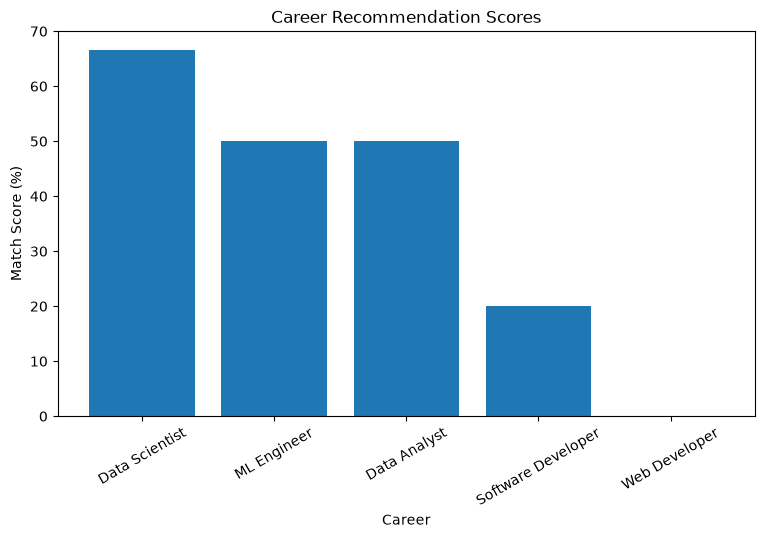

In [53]:
plt.figure(figsize=(9, 5))
plt.bar(
    recommendations["career"],
    recommendations["match_score"])
plt.xlabel("Career")
plt.ylabel("Match Score (%)")
plt.title("Career Recommendation Scores")
plt.xticks(rotation=30)
plt.show()

In [55]:
print("Career Recommendation")
print("Career:", top_career["career"])
print("Match Score:", top_career["match_score"], "%")
print("Skills to Learn:")

for skill in top_career["missing_skills"]:
    print("-", skill)
print("\nTop 3 Careers:")

for i, career in enumerate(top_careers["career"], 1):
    print(i, career)

Career Recommendation
Career: Data Scientist
Match Score: 66.67 %
Skills to Learn:
- Statistics
- NumPy

Top 3 Careers:
1 Data Scientist
2 ML Engineer
3 Data Analyst


In [58]:
import json
data = {
    "career": top_career["career"],
    "match_score": top_career["match_score"],
    "skills_to_learn": top_career["missing_skills"]}

with open("recommendation.json", "w") as file:
    json.dump(data, file, indent=4)
print("Saved successfully")

Saved successfully


In [ ]:
recommendations.to_csv(
    "career_recommendations.csv",
    index=False)
print("Saved successfully")

Saved successfully


In [73]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [74]:
final_model = lr
print("Final Model: Logistic Regression")

Final Model: Logistic Regression


In [84]:
import joblib
pca = joblib.load("../pca.pkl")

In [86]:
scaler = joblib.load("../standard_scaler.pkl")

In [87]:
final_model = joblib.load("../final_model.pkl")


C:\Users\Gauri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Gauri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [88]:
kmeans = joblib.load("../kmeans_model.pkl")

C:\Users\Gauri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.9.0 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
